## **PROJECT: Ridge Regression With Hyperparameter Tuning**
--- 

### **Import Libraries**
---

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures

### **Load Dataset**
---

In [48]:
data = fetch_california_housing()

X = data.data
y = data.target

df = pd.DataFrame(X,columns=data.feature_names)
df["target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### **Train-Test Split**
---

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### **Feature Scaling**
---

In [50]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **Baseline Model (Linear Regression)**
---

In [59]:
lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

lr_y_pred = lr_model.predict(X_test)

print(lr_model.score(X_train,y_train))
print(lr_model.score(X_test,y_test))

0.6125511913966952
0.575787706032451


### **Model Evaluation**
---

In [52]:
print("Linear MSE: ",mean_squared_error(y_test,lr_y_pred))
print("Linear R2 Score: ",r2_score(y_test,lr_y_pred))

Linear MSE:  0.5558915986952442
Linear R2 Score:  0.575787706032451


### **Polynomial Regression**
---

In [60]:
poly = PolynomialFeatures(degree=2)

poly_X_train = poly.fit_transform(X_train)
poly_X_test = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(poly_X_train,y_train)

poly_y_pred = poly_model.predict(poly_X_test)

print("Polynomial MSE: ",mean_squared_error(y_test,poly_y_pred))
print("Polynomial R2 Score: ",r2_score(y_test,poly_y_pred))
print(poly_model.score(poly_X_train,y_train))
print(poly_model.score(poly_X_test,y_test))

Polynomial MSE:  0.4643015238301244
Polynomial R2 Score:  0.6456819729261888
0.6852681982344955
0.6456819729261888


### **Ridge + Hyperparameter Tuning**
---

In [54]:
ridge = Ridge()

params = {
    "alpha":[0.0001,0.001,0.01,0.1,1,10,100]
}

grid = GridSearchCV(ridge,params,cv=5,scoring="r2")
grid.fit(poly_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are al

In [70]:
print("Best Alpha: ",grid.best_params_)
best_model = grid.best_estimator_

Best Alpha:  {'alpha': 100}


### **Final Evaluation**
---

In [61]:
R_y_pred = best_model.predict(poly_X_test)

print("Ridge MSE: ",mean_squared_error(y_test,R_y_pred))
print("Ridge R2 Score: ",r2_score(y_test,R_y_pred))
print(best_model.score(poly_X_train,y_train))
print(best_model.score(poly_X_test,y_test))

Ridge MSE:  0.4474044795486867
Ridge R2 Score:  0.6585764543911437
0.6764344307244858
0.6585764543911437


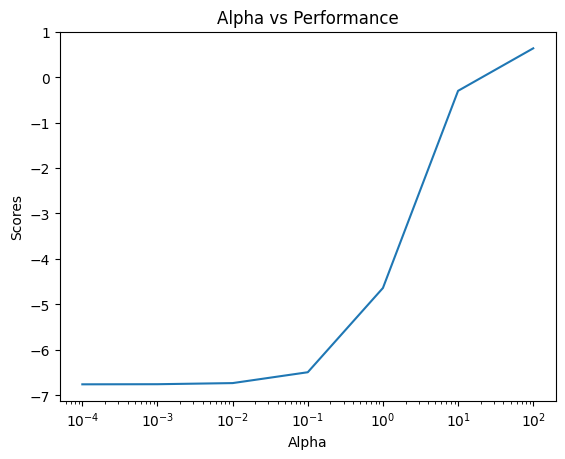

In [69]:
alphas = params['alpha']
scores = grid.cv_results_['mean_test_score']

plt.plot(alphas,scores)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Scores")
plt.title("Alpha vs Performance")
plt.show()